# COE 311k Midterm Project
## U.S. GDP Growth Rate Analysis Using Least Squares, Polynomial Fitting, and Cubic Splines

## Introduction

In this analysis I will analyze the dataset of the U.S. GDP growth rate using three different methods: least squares, polynomial fitting, and cubic spline interpolation. The dataset is given by the U.S. Bureau of Economic Analysis (BEA) and contains seasonally adjusted annual rate (SAAR) of real GDP growth, in percent, quarterly from 2010 to 2023. The data mainly includes relatively stable increases over the years, however there are noticable outliers between 2020 and 2021 due to the COVID-19 pandemic. The methods represent two different approaches to analyzing the data. The least squares and polynomial fitting methods represent approximation, where the models capture overall trends without passing through each point. The cubic spline method represents interpolation, where the function exactly matches all given data. My goal is to implement each of these methods from scratch and then compare the methods under different conditions.

### Data

The data consists of quarterly GDP growth percentages from 2010 to 2023. I have indexed the quarters so that x indices indicate each new quarter after the first data point instead of the inconsistent structure that was given.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

#Data

quarters = [
    "2010 Q1", "2011 Q1", "2012 Q1", "2013 Q1", "2014 Q1", "2014 Q3", "2015 Q2", "2016 Q1", 
    "2016 Q3", "2016 Q4", "2017 Q1", "2018 Q1", "2019 Q1", "2020 Q1", "2020 Q2", "2020 Q3", 
    "2021 Q1", "2022 Q1", "2023 Q2", "2023 Q4"]

y = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 
    2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

def quarter_to_index(label):
    year_str, q_str = label.split()
    year = int(year_str)
    quarter = int(q_str[1])
    return (year - 2010)*4 + quarter

x = np.array([quarter_to_index(label) for label in quarters])

print("Quarters:", quarters)
print("\nGDP growth values y:", y)
print("\nIndices x:", x)
print("\nNumber of points n =", len(x))

Quarters: ['2010 Q1', '2011 Q1', '2012 Q1', '2013 Q1', '2014 Q1', '2014 Q3', '2015 Q2', '2016 Q1', '2016 Q3', '2016 Q4', '2017 Q1', '2018 Q1', '2019 Q1', '2020 Q1', '2020 Q2', '2020 Q3', '2021 Q1', '2022 Q1', '2023 Q2', '2023 Q4']

GDP growth values y: [  1.7   0.1   2.3   2.7   1.7   5.    3.    1.5   3.5   1.8   1.3   2.5
   3.1  -5.1 -28.1  33.8   6.3  -1.6   2.4   3.3]

Indices x: [ 1  5  9 13 17 19 22 25 27 28 29 33 37 41 42 43 45 49 54 56]

Number of points n = 20


## Part A - Cubic Spline Interpolation

### A1:
To construct a natural cubic spline interpolant through the full dataset, I define a piecewise cubic polynomial on each interval between data points, ensuring smoothness at the data points. 

The spline must satisfy these continuity conditions:
- C0: The spline passes through all data points
- C1: The first derivative is continuous at each interior data point
- C2: The second derivative is continuous at each interior data point

Using these conditions, I set up a system of linear equations for the second derivatives, maintaining that the second derivatives need to match at each internal point. As a boundary condition for a natural cubic spline, I set the second derivatives at the endpoints to zero. This reduced the number of unknowns to n-2, which equals 18 in this case given the 20 data points. 

The resulting system is tridiagonal, meaning each equation involves only three neighboring unknowns. I construct the subdiagonal, main diagonal, and superdiagonal vectors and solve the system using the Thomas algorithm.

Since this dataset has n = 20 points, the system has 18 unknowns, resulting in an (18 x 18) linear system.

In [13]:
## A1 Code

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)
    
    a = np.zeros(n - 3) # subdiagonal
    b = np.zeros(n - 2) # main diagonal
    c = np.zeros(n - 3) # superdiagonal
    d = np.zeros(n - 2) # right-hand side
    
    for j in range(n - 2):
        i = j + 1
        
        b[j] = 2 * (h[i - 1] + h[i])
        d[j] = 6 * (((y[i+1] - y[i]) / h[i]) - ((y[i] - y[i-1]) / h[i-1]))
        
        if j > 0:
            a[j - 1] = h[i - 1]
            
        if j < n - 3:
            c[j] = h[i]
            
    return a, b, c, d, h


def thomas_algorithm(a, b, c, d):
    """
    Solve a tridiagonal linear system using the Thomas algorithm.

    a : subdiagonal, length n-1
    b : main diagonal, length n
    c : superdiagonal, length n-1
    d : right-hand side, length n
    """
    n = len(b)

    # Copies
    a_copy = a.copy()
    b_copy = b.copy()
    c_copy = c.copy()
    d_copy = d.copy()
    
    # Forward elimination
    for i in range(1, n):
        w = a_copy[i - 1] / b_copy[i - 1]
        b_copy[i] = b_copy[i] - w * c_copy[i - 1]
        d_copy[i] = d_copy[i] - w * d_copy[i - 1]

    # Back substitution
    x_solution = np.zeros(n)
    x_solution[-1] = d_copy[-1] / b_copy[-1]

    for i in range(n - 2, -1, -1):
        x_solution[i] = (d_copy[i] - c_copy[i] * x_solution[i + 1]) / b_copy[i]

    return x_solution


def compute_second_derivative(x, y):
    n = len(x)

    a,b,c,d,h = setup_tridiagonal_matrix(x,y)
    
    M_interior = thomas_algorithm(a, b, c, d)

    M = np.zeros(n)
    M[1:-1] = M_interior

    return M, h, a, b, c, d


def evaluate_spline(x, y, M, xeval):
    n = len(x)
    h = np.diff(x)

    i = np.searchsorted(x, xeval, side='right') - 1
    i = np.clip(i, 0, n - 2)

    hi = h[i]
    dx_left = xeval - x[i]
    dx_right = x[i+1] - xeval

    yeval = (
        (M[i] / (6*hi)) * dx_right**3 + 
        (M[i+1] / (6*hi)) * dx_left**3 + 
        (y[i] /hi - M[i] *hi/6) * dx_right + 
        (y[i+1] /hi - M[i+1] * hi/6) * dx_left
    )
    return yeval


M, h, a, b, c, d = compute_second_derivative(x, y)

print("Interval widths h:", h)

print("\nSubdiagonal a:", a)

print("\nMain diagonal b:", b)

print("\nSuperdiagonal c:", c)

print("\nRight hand side d:", d)

print("\nSecond derivatives M:", M)

print("\nNumber of interior unknowns:", len(M) - 2)

Interval widths h: [4 4 4 4 2 3 3 2 1 1 4 4 4 1 1 2 4 5 2]

Subdiagonal a: [4. 4. 4. 2. 3. 3. 2. 1. 1. 4. 4. 4. 1. 1. 2. 4. 5.]

Main diagonal b: [16. 16. 16. 12. 10. 12. 10.  6.  4. 10. 16. 16. 10.  4.  6. 12. 18. 14.]

Superdiagonal c: [4. 4. 4. 2. 3. 3. 2. 1. 1. 4. 4. 4. 1. 1. 2. 4. 5.]

Right hand side d: [   5.7    -2.7    -2.1    11.4   -13.9     1.      9.    -16.2     7.2
    4.8    -0.9   -13.2  -125.7   509.4  -453.9    70.65   16.65   -2.1 ]

Second derivatives M: [ 0.00000000e+00  3.95919853e-01 -1.58679413e-01 -4.36202203e-01
  1.37848822e+00 -1.69852494e+00  1.09424311e-01  1.59416103e+00
 -3.63494160e+00  2.42132754e+00  1.14963145e+00 -2.27941050e+00
  7.74301054e+00 -3.19926317e+01  1.63254275e+02 -1.11624467e+02
  2.62962632e+01 -5.41405611e+00  1.78359147e+00  0.00000000e+00]

Number of interior unknowns: 18


### A2:
I now use the natural cubic spline contructed from the selected GDP growth data and evaluate the spline at every quarter from 2010 Q1 through 2023 Q4. 

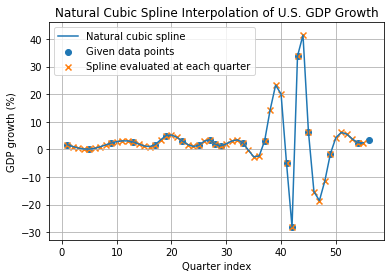

In [14]:
## A2 Code

x_full = np.arange(1, 56)
y_full = evaluate_spline(x, y, M, x_full)

# Plot
plt.scatter(x, y, label="Given data points")
plt.plot(x_full, y_full, label="Natural cubic spline")
plt.scatter(x_full, y_full, label="Spline evaluated at each quarter", marker='x')
plt.xlabel("Quarter index")
plt.ylabel("GDP growth (%)")
plt.title("Natural Cubic Spline Interpolation of U.S. GDP Growth")
plt.grid(True)
plt.legend()
plt.show()

The natural cubic spline is smooth and passes exactly through each original data point along with the rest of the evaluated points as expected. The spline is visually smooth across each interval, however it may look slightly rough when looking at large changes in the data because the graph does not include points between the intervals. However, if more points between intervals were included in the graph, the graph would be perfectly smooth. Mathematically, the line is completely smooth and there are no rough spots or sharp turns that would be present in the graph. The curve changes gradually in most regions, then the much larger changes are attributed to the COVID-19 pandemic. Overall, the graph is visually smooth and reasonable given the extreme circumstances of the pandemic.

### A3
The spline passes exactly through the outlier caused by COVID-19 (-28.1%), which means it also affects the drop and rebound of the values around that point, creating a local distortion that may not be an exactly accurate representation of the trend.

The Runge Phenomenon is the problem with large oscillations at the edges of an interval that occur when using a high-degree polynomial to interpolate. Cubic splines help to minimize this problem because they use piecewise cubic functions rather than one large polynomial. This ensures the line remains smooth and free of the large oscillations at the edges of the intervals.

Cubic splines are still prone to outliers though since the line passes exactly through each point, including the outlier, still causing local distortions.

Cubic splines are very useful to exactly interpolate data, however if the goal were to analyze the overall trend in data, methods like smoothing splines or weighted least squares would be less prone to outliers and better show the broader trend.

In this case, the extreme outlier caused by the COVID-19 pandemic may be negatively representing the true trend in GDP growth, so a smoothing spline or a weighted least squares method would be better at showing the overall economic growth trend since they reduce the influence of extreme outliers.

## Part B [HW5] [CH9, CH10, CH11]

### B1
Now I will fit a degree-4 polynomial to the data using the least squares method. 

The least squares method is an approximation, unlike the cubic spline method which is an interpolation, so it does not need to directly pass through every point. 

To construct the polynomial fit, I make a Vandermonde matrix using powers of the indices and solve to get the coefficients. Then, I compare the polynomial curve to the natural cubic spline and compare the results.

Degree-4 polynomial coefficients:
[ 2.11403340e-01  4.12733208e-01 -2.11036921e-02  3.57892276e-04
 -1.71060095e-06]

Shape of Vandermonde matrix: (20, 5)

Condition number of V:
18197798.18154116

Condition number of V^T V:
331159708504818.56


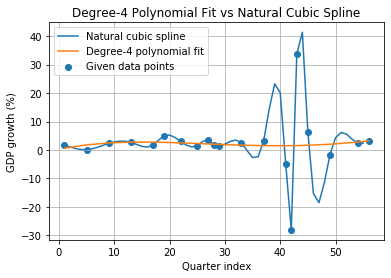

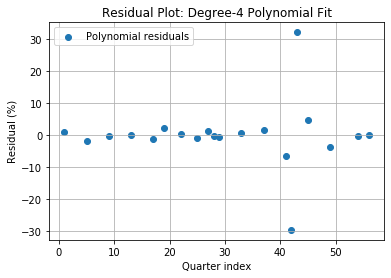

Polynomial RMSE: 10.031440678677116


In [15]:
## B1 Code

def polynomial_least_squares(x, y, degree):
    V = np.vander(x, degree + 1, increasing=True)
    normal_matrix = V.T @ V
    rhs = V.T @ y
    coefficients = np.linalg.solve(normal_matrix, rhs)
    return coefficients, V, normal_matrix, rhs

def evaluate_polynomial(coefficients, xeval):
    xeval = np.asarray(xeval, dtype=float)
    yeval = np.zeros_like(xeval, dtype=float)

    for k in range(len(coefficients)):
        yeval += coefficients[k] * xeval**k

    return yeval

# Fit degree-4 polynomial
degree = 4
poly_coeffs, V, normal_matrix, poly_rhs = polynomial_least_squares(x, y, degree)

# Evaluate polynomial at original points
y_poly = evaluate_polynomial(poly_coeffs, x)

y_spline = evaluate_spline(x, y, M, x_full)

print("Degree-4 polynomial coefficients:")
print(poly_coeffs)

print("\nShape of Vandermonde matrix:", V.shape)

print("\nCondition number of V:")
print(np.linalg.cond(V))

print("\nCondition number of V^T V:")
print(np.linalg.cond(normal_matrix))

#Plot
plt.scatter(x, y, label="Given data points")
plt.plot(x_full, y_spline, label="Natural cubic spline")
plt.plot(x, y_poly, label="Degree-4 polynomial fit")
plt.xlabel("Quarter index")
plt.ylabel("GDP growth (%)")
plt.title("Degree-4 Polynomial Fit vs Natural Cubic Spline")
plt.grid(True)
plt.legend()
plt.show()

# Residuals
poly_residuals = y - y_poly

# Residual plot
plt.scatter(x, poly_residuals, label="Polynomial residuals")
plt.xlabel("Quarter index")
plt.ylabel("Residual (%)")
plt.title("Residual Plot: Degree-4 Polynomial Fit")
plt.grid(True)
plt.legend()
plt.show()

poly_rmse = np.sqrt(np.mean(poly_residuals**2))
print("Polynomial RMSE:", poly_rmse)

The degree-4 polynomial is a least squares approximation, meaning it does not pass through every point but instead balances the data in order to represent the overall shape of the dataset. This means it is better at representing the overall trend while the natural cubic spline is better for matching each individual data point exactly. 

These visual graphs show the trade-offs between the approximation and interpolation methods. Interpolation goes exactly through each point, whereas approximation shows the general trend in the data. The graph shows how the approximation curve shows more of the trends in the global economic growth rate and mostly neglects the outliers that were cause by the pandemic, however is is more subtle and could be less accurate on small intervals than the interpolation.

### B2
In order to analyze the global trend without the outliers caused by the pandemic, I fit a least squares linear model that excludes the COVID quarters from 2020 Q1 through 2021 Q1.

The linear least squares model has the form y = mx + b where m is the slope and b is the intercept. 

Slope: -0.001906988188976378
Intercept: 2.194285187007874


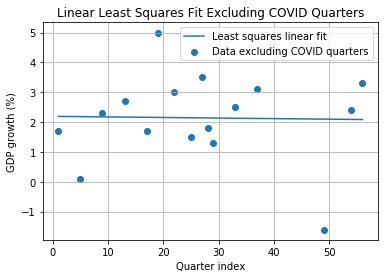

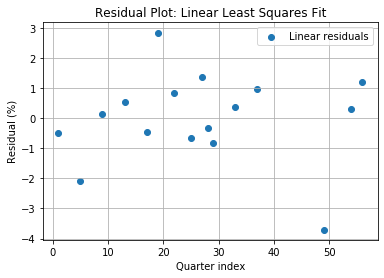

In [16]:
## B2 Code

def linear_least_squares(x, y):
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x**2)

    m = ((n * sum_xy) - (sum_x * sum_y)) / ((n * sum_x2) - sum_x**2)
    b = (sum_y - (m * sum_x)) / n

    return m, b

# Exclude COVID quarters
covid_quarters = (x >= 41) & (x <= 45)
x_linear = x[~covid_quarters]
y_linear = y[~covid_quarters]

# Compute least squares line
m, b = linear_least_squares(x_linear, y_linear)

y_line = m * x_linear + b

print("Slope:", m)
print("Intercept:", b)

#Plot
plt.scatter(x_linear, y_linear, label="Data excluding COVID quarters")
plt.plot(x_linear, y_line, label="Least squares linear fit")
plt.xlabel("Quarter index")
plt.ylabel("GDP growth (%)")
plt.title("Linear Least Squares Fit Excluding COVID Quarters")
plt.grid(True)
plt.legend()
plt.show()

# Residuals
line_residuals = y_linear - y_line

plt.scatter(x_linear, line_residuals, label="Linear residuals")
plt.xlabel("Quarter index")
plt.ylabel("Residual (%)")
plt.title("Residual Plot: Linear Least Squares Fit")
plt.grid(True)
plt.legend()
plt.show()

The slope of this linear model represents the average rate of change in GDP growth over the quarter index after excluding the COVID quarters. This slope is a very small number, meaning there is very little consistent upward or downward trend in the data. 

A linear trend does not make economic sense for GDP growth data because it is influenced by so many different factors and cycles that affect it non-linearly. A straight line would assume that GDP growth is fairly linear, however that is not the case and this model fails to show the fluctuations in the data. 

The residual graph further shows that the data does not follow a linear pattern and instead is all scattered, meaning a best-fit line would be quite inaccurate for many of the data points. 

## Part C

## C1
For a policymaker who needs to estimate GDP growth for a quarter between two known data points, I would recommend the cubic spline rather than the polynomial fit. The cubic spline uses interpolation rather than approximation, therefore it passes directly through each data point and maintaining continuity. This ensures it is a smooth curve, which is perfect for interpolating values between two known points.

Degree-4 polynomial fitting, however, is a least squares approximation. It does well at showing the overall trend in the data but it does not accurately give the specific interpolation between two points over a shorter interval. The spline is better used for interpolating specific values while the polynomial fit is better for showing the broader trend.

For example, if the policymaker wanted to estimate GDP growth between 2016 Q1 and 2016 Q3, they would be better off using cubic spline interpolation to understand the short-term economic changes during that time. This method would be accurate as it smoothly connects the two data points and shows the local behavior rather than the polynomial fiting, which would be influenced by the long-term data including the COVID data points all the way in 2020, so it would be less accurate for short-term understanding.

## Big O Discussion
Big O notation represents how the computational cost of an algorithm grows as the size of the input increases. The linear least squares method has a complexity of O(n). Degree-4 polynomial least squares has a complexity of O(n). Natural cubic spline solved with the Thomas algorithm also has a complexity of O(n).

Since each method gives linear Big O notation, the Big O analysis does not change my recommendation. The cubic spline is still the best choice because of its smoothness and that it goes exactly through all data points. 

## Conclusion

In this project, I applied least squares linear regression, degree-4 polynomial fitting, and natural cubic spline interpolation to model U.S. GDP growth data from 2010 to 2023. 

The cubic spline worked best for interpolation as it passed through all data points and remained smooth across intervals, however it was prone to local distortion from outliers in the data. The degree-4 polynomial fitting was better at showing the overall trend of the data because it used approximation instead of passing directly through each data point, limiting that susceptibility to outliers. The linear least squares model provided a simple best-fit line but did not accurately represent the fluctuations in the data. 

I have learned that the choice of method for analyzing data depends on the goal of the analysis. Cubic splines ended up being better for estimating values between known points, while least squares methods are better at showing trends in the whole dataset and ignoring the outliers. 

Overall, the most important step when analyzing data is to pick a method which most accurately meets your goals. Even using multiple methods and comparing them leads to a better understanding of data and a more fulfilling analysis